#Входная модель

Задача: кластрезировать входные данные для дальнейшего обучения моделей.

Возможные модели: k-mean, Agglomerative Clustering (иерархическая кластеризация), DBSCAN, простая нейронная сеть.

##Загрузка библиотек и синтез данных

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, make_scorer
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('future.no_silent_downcasting', True)

In [2]:
pip install --upgrade gdown

In [3]:
#сгенерируем данные, которые будут максимально похожи на наши реальные
columns = ['Лейкоциты (WBC)', 'Эритроциты (RBC)', 'Гемоглобин (HGB)', 'Гематокрит (HCT)', 'Средний объем эритроцита (MCV)']

mean_wbc = 7.0
mean_rbc = 5.0
mean_hgb = 140
mean_hct = 45
mean_mcv = 90
std = 100
size = 300

wbc_data = np.random.normal(mean_wbc, std / mean_wbc * 1.5, size)  # Лейкоциты
rbc_data = np.random.normal(mean_rbc, std / mean_rbc * 1.5, size)  # Эритроциты
hgb_data = np.random.normal(mean_hgb, std / mean_hgb * 1.5, size)  # Гемоглобин
hct_data = np.random.normal(mean_hct, std / mean_hct * 1.5, size)  # Гематокрит
mcv_data = np.random.normal(mean_mcv, std / mean_mcv * 1.5, size)  # MCV

wbc_data = np.clip(wbc_data, 2, None)
rbc_data = np.clip(rbc_data, 2, None)
hgb_data = np.clip(hgb_data, 90, None)
hct_data = np.clip(hct_data, 20, None)
mcv_data = np.clip(mcv_data, 60, None)

data = {
    'Лейкоциты (WBC)': wbc_data,
    'Эритроциты (RBC)': rbc_data,
    'Гемоглобин (HGB)': hgb_data,
    'Гематокрит (HCT)': hct_data,
    'Средний объем эритроцита (MCV)': mcv_data
}

df = pd.DataFrame(data=data, columns=columns)

In [4]:
df.head(5)

,Лейкоциты (WBC),Эритроциты (RBC),Гемоглобин (HGB),Гематокрит (HCT),Средний объем эритроцита (MCV)
0,8.029784,2.000000,138.321670,47.006402,86.330817
1,2.000000,43.267358,138.345982,42.839242,89.908672
2,18.634534,17.881252,139.887527,44.783063,90.254662
3,2.000000,32.649384,138.304246,49.843271,89.824522
4,13.384843,9.474918,139.740662,43.015642,91.037932


In [5]:
df.describe()

,Лейкоциты (WBC),Эритроциты (RBC),Гемоглобин (HGB),Гематокрит (HCT),Средний объем эритроцита (MCV)
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,12.230631,16.142209,139.961790,44.682390,89.966089
std,12.927866,19.397723,1.075288,3.558548,1.649752
min,2.000000,2.000000,136.068528,35.430223,84.560894
25%,2.000000,2.000000,139.302876,42.547832,88.962730
50%,6.205248,6.046840,139.945382,44.502304,89.984406
75%,19.672163,25.384608,140.660955,47.276642,91.110028
max,60.502634,91.407042,142.501305,54.893875,94.185160


In [6]:
 RANDOM_STATE = 42
 Ks = range(1, 11)

##Ближайшие соседи

In [7]:
#подберем оптимальное количество кластеров
sum_squared_distances = []

In [8]:
for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans.fit(df)
    sum_squared_distances.append(kmeans.inertia_)

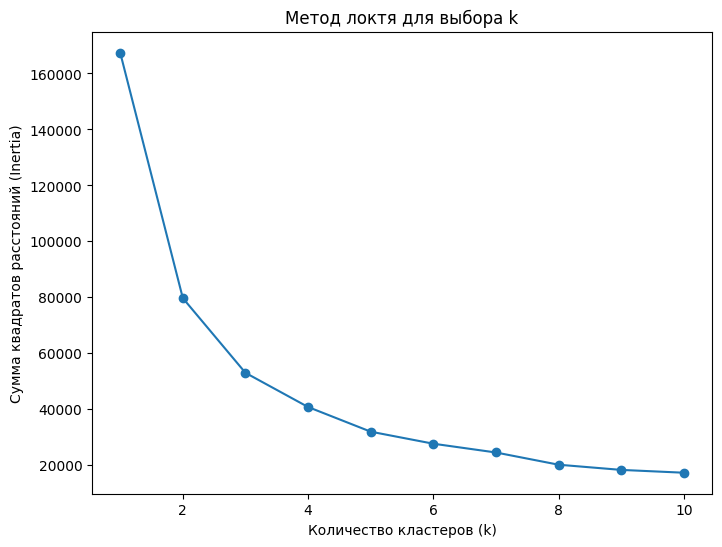

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(Ks, sum_squared_distances, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (Inertia)')
plt.title('Метод локтя для выбора k')
plt.show()

In [10]:
k_best = 4

In [11]:
kmeans_best = KMeans(n_clusters=k_best, random_state=RANDOM_STATE)
kmeans_best.fit(df)

KMeans(n_clusters=4, random_state=42)

In [12]:
#изучим центроиды
centroids = kmeans_best.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns=df.columns)

centroid_df.insert(0, 'Кластер', centroid_df.index)

print("Центроиды кластеров:")
print(centroid_df)

Центроиды кластеров:
   Кластер  Лейкоциты (WBC)  Эритроциты (RBC)  Гемоглобин (HGB)  \
0        0         5.001353          4.492036        139.793036   
1        1        17.256300         57.194916        140.254200   
2        2        29.580553          6.921790        139.992791   
3        3         8.318309         31.245255        140.190067   

   Гематокрит (HCT)  Средний объем эритроцита (MCV)  
0         44.423762                       89.988643  
1         44.222519                       89.421502  
2         44.539761                       89.921785  
3         45.859416                       90.319435  


In [13]:
labels = kmeans_best.labels_
silhouette_avg = silhouette_score(df, labels)
print(f'Средний силуэтный коэффициент: {silhouette_avg:.3f}')

Средний силуэтный коэффициент: 0.455


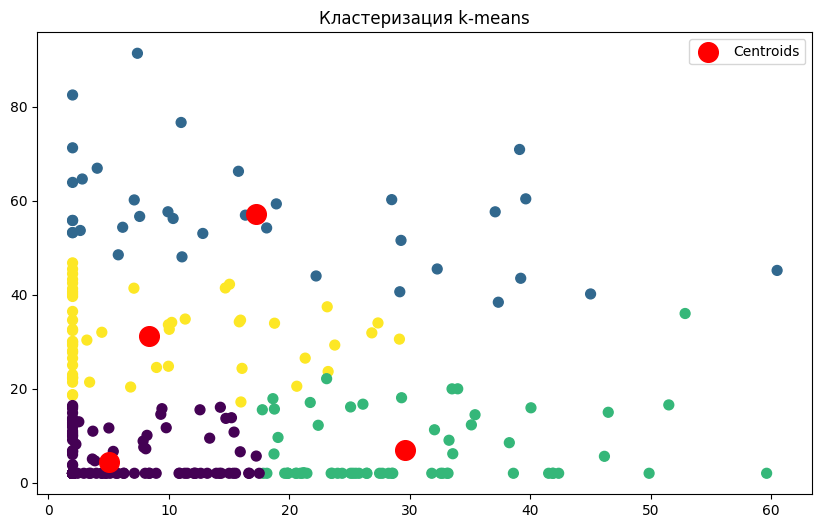

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=labels, cmap='viridis', s=50)

plt.scatter(centroids[:, 0], centroids[:, 1], marker='o', s=200, c='red', label='Centroids')

plt.title('Кластеризация k-means')
plt.legend()
plt.show()

##Agglomerative Clustering

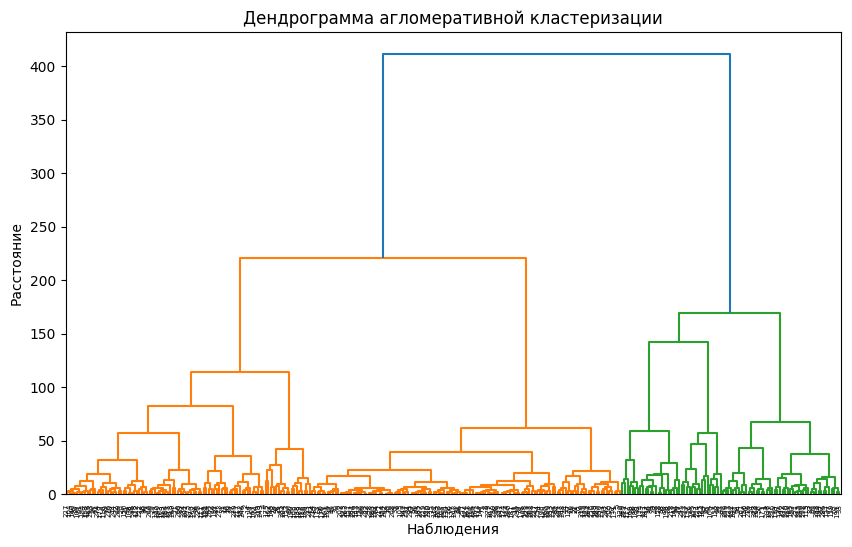

In [15]:
linked = linkage(df, method='ward', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Дендрограмма агломеративной кластеризации')
plt.xlabel('Наблюдения')
plt.ylabel('Расстояние')
plt.show()

In [16]:
silhouette_scores_ac = []

for k in Ks:
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = clustering.fit_predict(df)
    unique_labels = set(labels)
    if len(unique_labels) > 1:
      score = silhouette_score(df, labels)
      silhouette_scores_ac.append(score)
    else:
      silhouette_scores_ac.append(-1)

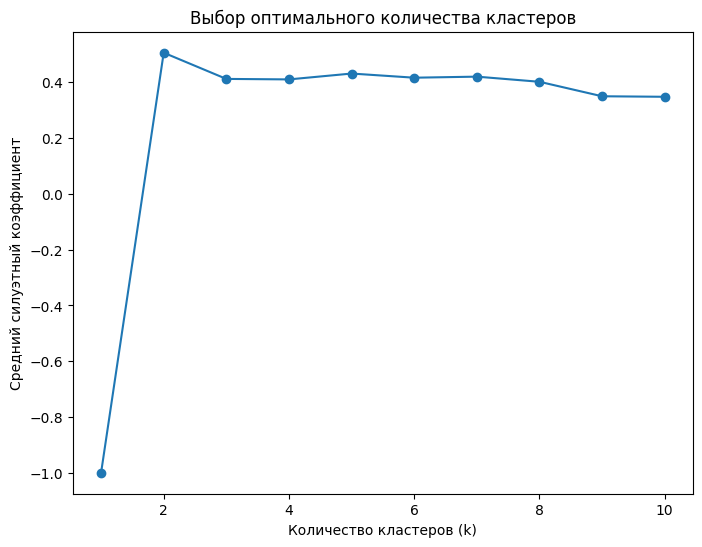

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(Ks, silhouette_scores_ac, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Средний силуэтный коэффициент')
plt.title('Выбор оптимального количества кластеров')
plt.show()

In [18]:
#по дендрограмме оптимальное количесвто кластеров 4
#при автоматическом подборе количества кластеров сталкиваюсь с проблемой схлопывания в один кластер
#в принципе это видно и на диаграмме подбора
k_best_ac = 4

In [19]:
clustering_best = AgglomerativeClustering(n_clusters=k_best_ac, linkage='ward', metric='euclidean')
labels_ac = clustering_best.fit_predict(df)

In [20]:
df_ac = df.copy()

In [21]:
df_ac['cluster'] = labels_ac

In [22]:
representatives = df_ac.groupby('cluster').mean()
representatives

,Лейкоциты (WBC),Эритроциты (RBC),Гемоглобин (HGB),Гематокрит (HCT),Средний объем эритроцита (MCV)
cluster,,,,,
0,19.296593,54.779741,140.374573,44.265016,89.626632
1,24.260750,7.064593,139.982249,44.389810,89.946616
2,3.017611,4.423062,139.765169,44.609332,89.940983
3,5.429076,32.703242,140.082492,45.831081,90.359598


In [23]:
silhouette_avg_ac = silhouette_score(df, labels_ac)
print(f'Средний силуэтный коэффициент: {silhouette_avg_ac:.3f}')

Средний силуэтный коэффициент: 0.410


In [24]:
#для визуализации снизим размерность, т к аггломерация не предполагает наличие центроидов
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_ac.drop('cluster', axis=1))

In [25]:
reduced_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])
reduced_df['cluster'] = df_ac['cluster']

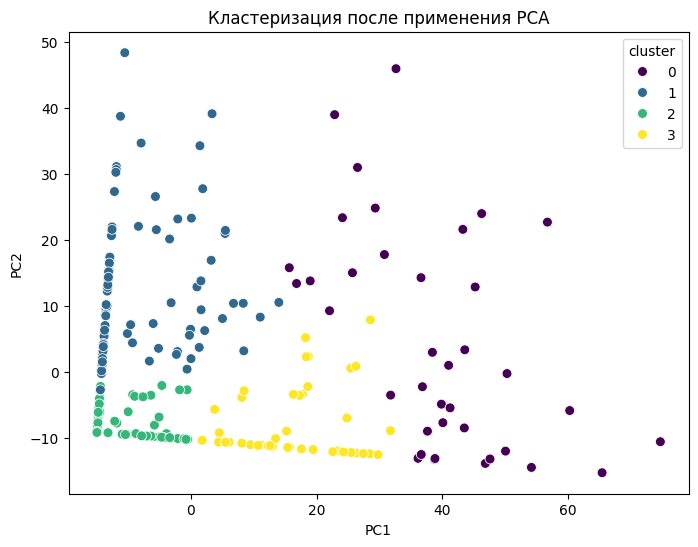

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=reduced_df, x='PC1', y='PC2', hue='cluster', palette='viridis', s=50)
plt.title('Кластеризация после применения PCA')
plt.show()

##DBSCAN

In [27]:
eps_values = np.linspace(0.1, 1.0, 10)
min_samples_values = range(2, 11)

best_score = -1
best_params = None

In [28]:
for eps in eps_values:
    for min_samples in min_samples_values:
        #тренировка модели
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(df)

        #оценка качества кластеризации
        if len(set(labels)) > 1:
        #убедимся, что образовалось хотя бы два кластера
            score = silhouette_score(df, labels)
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': min_samples}

#лучшие параметры
print(f"Лучшие параметры: {best_params}")
print(f"Лучший силуэтный коэффициент: {best_score:.3f}")

Лучшие параметры: {'eps': np.float64(1.0), 'min_samples': 2}
Лучший силуэтный коэффициент: -0.174


In [29]:
dbscan_best = DBSCAN(eps=0.8, min_samples=2)
labels_dbscan = dbscan.fit_predict(df)

In [30]:
df_db = df.copy()
df_db['cluster'] = labels_dbscan

In [31]:
representatives_db = df_db.groupby('cluster').mean()
representatives_db

,Лейкоциты (WBC),Эритроциты (RBC),Гемоглобин (HGB),Гематокрит (HCT),Средний объем эритроцита (MCV)
cluster,,,,,
-1,12.230631,16.142209,139.96179,44.68239,89.966089


In [32]:
#для визуализации снизим размерность, т к данный метод тоже не предполагает наличие центроидов
pca_db = PCA(n_components=2)
reduced_data_db = pca.fit_transform(df_db.drop('cluster', axis=1))

In [33]:
reduced_data_db = pd.DataFrame(reduced_data_db, columns=['PC1', 'PC2'])
reduced_data_db['cluster'] = df_db['cluster']

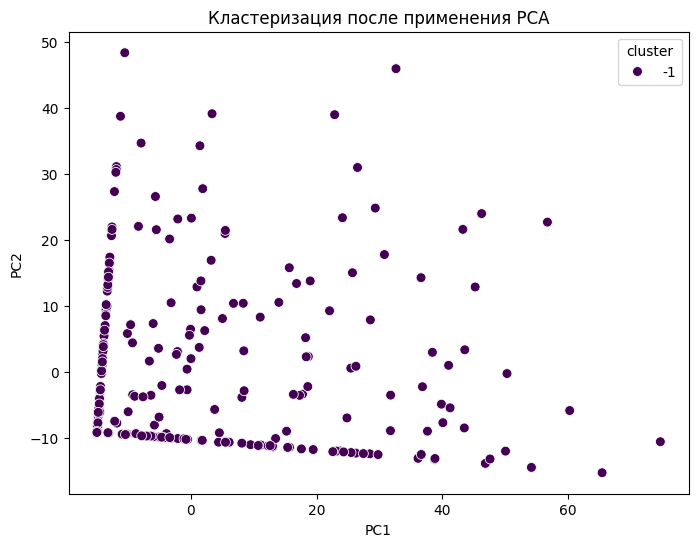

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=reduced_data_db, x='PC1', y='PC2', hue='cluster', palette='viridis', s=50)
plt.title('Кластеризация после применения PCA')
plt.show()

##Нейронная сеть

In [35]:
 #в работе

#Реальные данные

In [36]:
! gdown 1nxfzmyk-wZ5uQHSPlyeZiM4xCZ2IaZKi

Downloading...
From: https://drive.google.com/uc?id=1nxfzmyk-wZ5uQHSPlyeZiM4xCZ2IaZKi
To: /content/work_df.csv
100% 90.6k/90.6k [00:00<00:00, 42.2MB/s]


In [37]:
work = pd.read_csv('/content/work_df.csv')

In [38]:
work.head(3)

,ID истории болезни,ba_abs,ba_rel,blasty,cp,eo_abs,eo_rel,hct,hgb,ly_abs,ly_rel,mch,mchc,mcv,mo_abs,mo_rel,mpv,mxd_abs,mxd_rel,myelo,ne_abs,ne_rel,noclass_abs,noclass_rel,normobl_abs,normobl_rel,pal,pct,pdw,plasma,plcr,plt,prolym,promyelo,rbc,rdv_cv,rdv_sd,rdw,ret_abs,ret_rel,seg,soe_p,soe_v,wbc,yunye,Пол,Дата рождения пациента
0,05deb1af-cf40-11e9-80ba-901b0e633689,0.500000,0.366667,NaN,1.126667,1.300,1.733333,27.466667,88.333333,8.066667,13.300,37.733333,321.333333,117.433333,7.033333,16.233333,NaN,NaN,NaN,1.0,5.600000,63.633333,NaN,4.7,0.0,0.0,2.333333,NaN,NaN,NaN,NaN,101.000000,NaN,NaN,2.363333,NaN,NaN,21.333333,NaN,3.4,62.333333,12.666667,NaN,8.766667,1.666667,Ж,1938-04-03 00:00:00
1,06a83aaa-8e27-11ec-ab52-0050568844e6,0.952857,1.225000,NaN,0.600000,0.615,3.492500,53.000000,157.060000,15.623333,21.886,19.880000,242.020000,67.140000,1.011250,1.985000,8.950000,0.500000,4.5,NaN,9.564000,71.852000,NaN,NaN,NaN,NaN,1.000000,0.650000,12.800000,NaN,NaN,692.080000,NaN,NaN,7.892000,17.900000,42.800000,16.425000,NaN,NaN,63.250000,NaN,3.00,13.322000,1.000000,М,1973-11-18 00:00:00
2,0839c9c1-1109-11ef-8607-005056880ecb,0.701250,2.425000,1.333333,0.867500,0.295,1.450000,32.000000,110.636364,3.812143,13.080,28.636364,147.200000,82.000000,2.752500,7.900000,9.781818,0.966667,17.5,9.5,4.362857,72.257143,NaN,NaN,2.0,NaN,10.750000,0.301818,13.614286,NaN,NaN,310.272727,NaN,NaN,3.888182,17.428571,49.571429,16.250000,NaN,NaN,55.000000,NaN,36.25,6.827273,6.000000,Ж,1939-02-06 00:00:00


In [39]:
work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID истории болезни      242 non-null    object 
 1   ba_abs                  233 non-null    float64
 2   ba_rel                  241 non-null    float64
 3   blasty                  64 non-null     float64
 4   cp                      241 non-null    float64
 5   eo_abs                  240 non-null    float64
 6   eo_rel                  240 non-null    float64
 7   hct                     242 non-null    float64
 8   hgb                     242 non-null    float64
 9   ly_abs                  242 non-null    float64
 10  ly_rel                  242 non-null    float64
 11  mch                     242 non-null    float64
 12  mchc                    242 non-null    float64
 13  mcv                     242 non-null    float64
 14  mo_abs                  241 non-null    fl

In [40]:
x = work.drop('ID истории болезни', axis=1)

In [41]:
x['Дата рождения пациента'] = pd.to_datetime(x['Дата рождения пациента'], format='%Y-%m-%d %H:%M:%S')

In [42]:
x['Пол'] = x['Пол'].replace({'Ж': 0, 'М': 1}).astype(int)

In [43]:
today = datetime.now()

In [44]:
#вычисляем полный возраст
def calculate_age(birth_date):
    age = today.year - birth_date.year
    #если день рождения еще не наступил в этом году, вычесть один год
    if (today.month, today.day) < (birth_date.month, birth_date.day):
        age -= 1
    return age

In [45]:
x['age'] = x['Дата рождения пациента'].apply(calculate_age)
x = x.drop('Дата рождения пациента', axis = 1)

In [46]:
x.head(2)

,ba_abs,ba_rel,blasty,cp,eo_abs,eo_rel,hct,hgb,ly_abs,ly_rel,mch,mchc,mcv,mo_abs,mo_rel,mpv,mxd_abs,mxd_rel,myelo,ne_abs,ne_rel,noclass_abs,noclass_rel,normobl_abs,normobl_rel,pal,pct,pdw,plasma,plcr,plt,prolym,promyelo,rbc,rdv_cv,rdv_sd,rdw,ret_abs,ret_rel,seg,soe_p,soe_v,wbc,yunye,Пол,age
0,0.500000,0.366667,NaN,1.126667,1.300,1.733333,27.466667,88.333333,8.066667,13.300,37.733333,321.333333,117.433333,7.033333,16.233333,NaN,NaN,NaN,1.0,5.600,63.633333,NaN,4.7,0.0,0.0,2.333333,NaN,NaN,NaN,NaN,101.00,NaN,NaN,2.363333,NaN,NaN,21.333333,NaN,3.4,62.333333,12.666667,NaN,8.766667,1.666667,0,87
1,0.952857,1.225000,NaN,0.600000,0.615,3.492500,53.000000,157.060000,15.623333,21.886,19.880000,242.020000,67.140000,1.011250,1.985000,8.95,0.5,4.5,NaN,9.564,71.852000,NaN,NaN,NaN,NaN,1.000000,0.65,12.8,NaN,NaN,692.08,NaN,NaN,7.892000,17.9,42.8,16.425000,NaN,NaN,63.250000,NaN,3.0,13.322000,1.000000,1,51


In [47]:
imputer = SimpleImputer(strategy='mean')
x_imputed = imputer.fit_transform(x)

In [48]:
feature_names = x.columns
x_imputed_df = pd.DataFrame(x_imputed, columns=feature_names)

In [49]:
sum_squared_distances_r= []

for k in Ks:
    kmeans_r = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    kmeans_r.fit(x_imputed_df)
    sum_squared_distances_r.append(kmeans_r.inertia_)

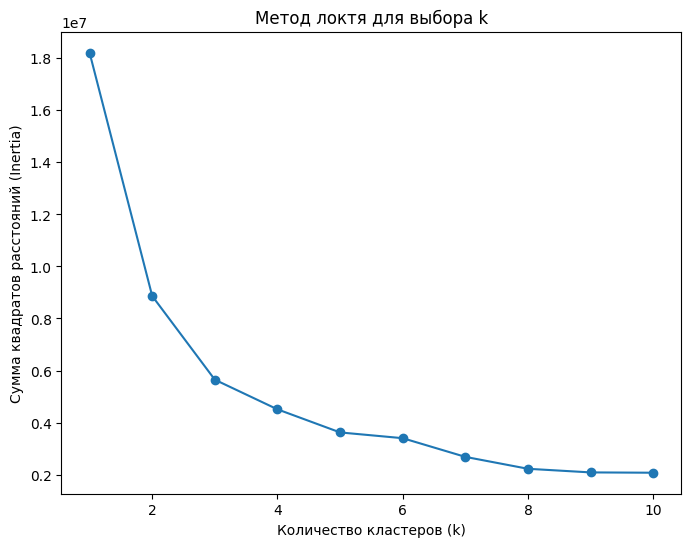

In [50]:
plt.figure(figsize=(8, 6))
plt.plot(Ks, sum_squared_distances_r, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (Inertia)')
plt.title('Метод локтя для выбора k')
plt.show()

In [51]:
k_best_r = 5

In [52]:
kmeans_best_r = KMeans(n_clusters=k_best_r, random_state=RANDOM_STATE)
labels_r = kmeans_best_r.fit(x_imputed_df)

In [53]:
labels_r = kmeans_best_r.labels_
centroids_r = kmeans_best_r.cluster_centers_

In [54]:
#изучим центроиды
centroids_r = kmeans_best_r.cluster_centers_
centroid_df_r = pd.DataFrame(centroids_r, columns=x_imputed_df.columns)

centroid_df_r.insert(0, 'Кластер', centroid_df_r.index)

print("Центроиды кластеров:")
print(centroid_df_r)

Центроиды кластеров:
   Кластер    ba_abs    ba_rel     blasty        cp    eo_abs    eo_rel  \
0        0  0.645795  1.567387   9.189485  0.816459  1.249610  2.598536   
1        1  0.681742  1.475580   9.249668  0.796993  1.640368  2.976280   
2        2  0.290016  1.322157  10.200988  0.881534  0.729325  1.688285   
3        3  0.433324  1.222042  14.551220  0.910732  0.765968  1.806370   
4        4  0.735499  2.006308   6.932377  0.835641  0.894827  1.723846   

         hct         hgb     ly_abs     ly_rel        mch        mchc  \
0  44.472207  141.245541  12.915660  23.941221  27.221126  276.260698   
1  36.779404  116.528774  12.051348  22.417411  26.683949  222.146234   
2  29.746116  100.542617  10.288841  32.293263  29.239309  138.278913   
3  37.120245  120.974706  15.996013  33.081666  30.330375  315.608343   
4  32.422307  107.031777   5.911275  16.984452  27.941505  153.642576   

         mcv    mo_abs     mo_rel       mpv   mxd_abs    mxd_rel     myelo  \
0  85.20130

In [55]:
silhouette_avg_r = silhouette_score(x_imputed_df, labels_r)
print(f'Средний силуэтный коэффициент: {silhouette_avg_r:.3f}')

Средний силуэтный коэффициент: 0.374


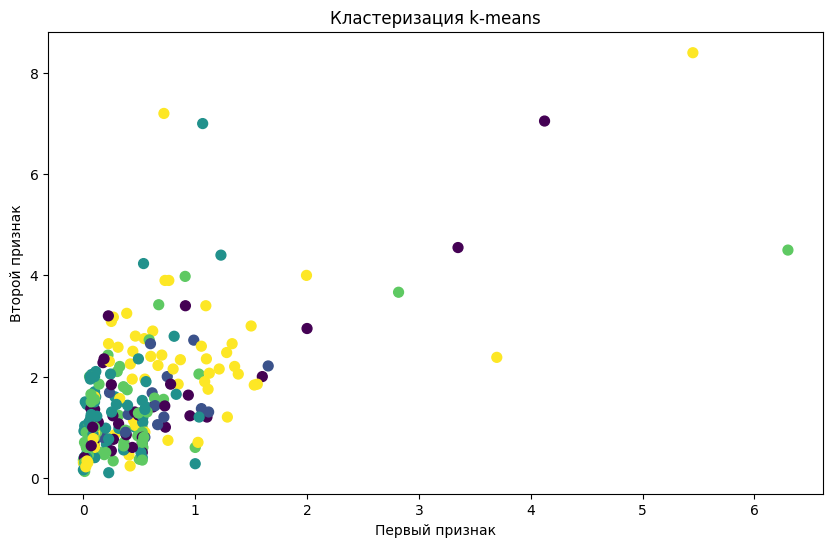

In [56]:
plt.figure(figsize=(10, 6))
plt.scatter(x_imputed_df.iloc[:, 0], x_imputed_df.iloc[:, 1], c=labels_r, cmap='viridis', s=50)
plt.title('Кластеризация k-means')
plt.xlabel('Первый признак')
plt.ylabel('Второй признак')
plt.show()